In [4]:
from geodata import load_map_data
from solvers import backtrack, backtrack_fc, min_conflicts, backtrack_ac3
from visualizer import show_map_image

import time
import geopandas as gpd

# Load variables and constraints
print("Loading map data...")
variables, neighbors = load_map_data("borders.geojson")

# Setup domain colors
colors = ["#E63946", "#2A9D8F", "#E9C46A", "#457B9D"]
print(f"Domain colors: {colors}")
domains = {v: colors.copy() for v in variables}

# Load data frame
print("Reading map...")
gdf = gpd.read_file("borders.geojson")

Loading map data...
Domain colors: ['#E63946', '#2A9D8F', '#E9C46A', '#457B9D']
Reading map...


Backtracking finished in 0.5665 seconds.


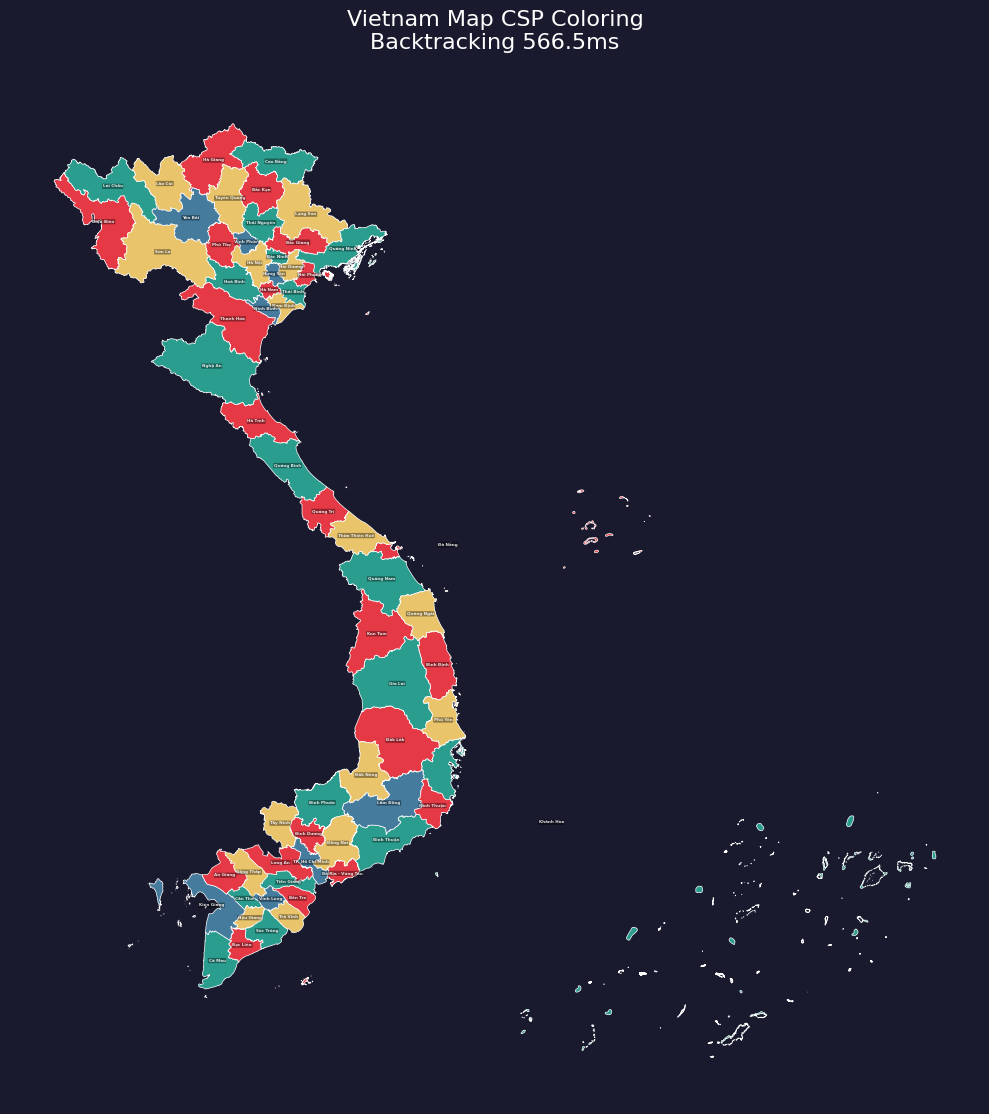

In [6]:
# ===== BACKTRACK =====
start_time = time.perf_counter()
backtrack_solution = backtrack(variables, domains, {}, neighbors)
end_time = time.perf_counter()
print(f"Backtracking finished in {end_time - start_time:.4f} seconds.")

if backtrack_solution:
    show_map_image(gdf,
                   solution=backtrack_solution, 
                   title=f"Vietnam Map CSP Coloring\nBacktracking {(end_time - start_time) * 1000:.1f}ms"
                   )
# =====================

Backtracking + Forward Checking finished in 0.0256 seconds.


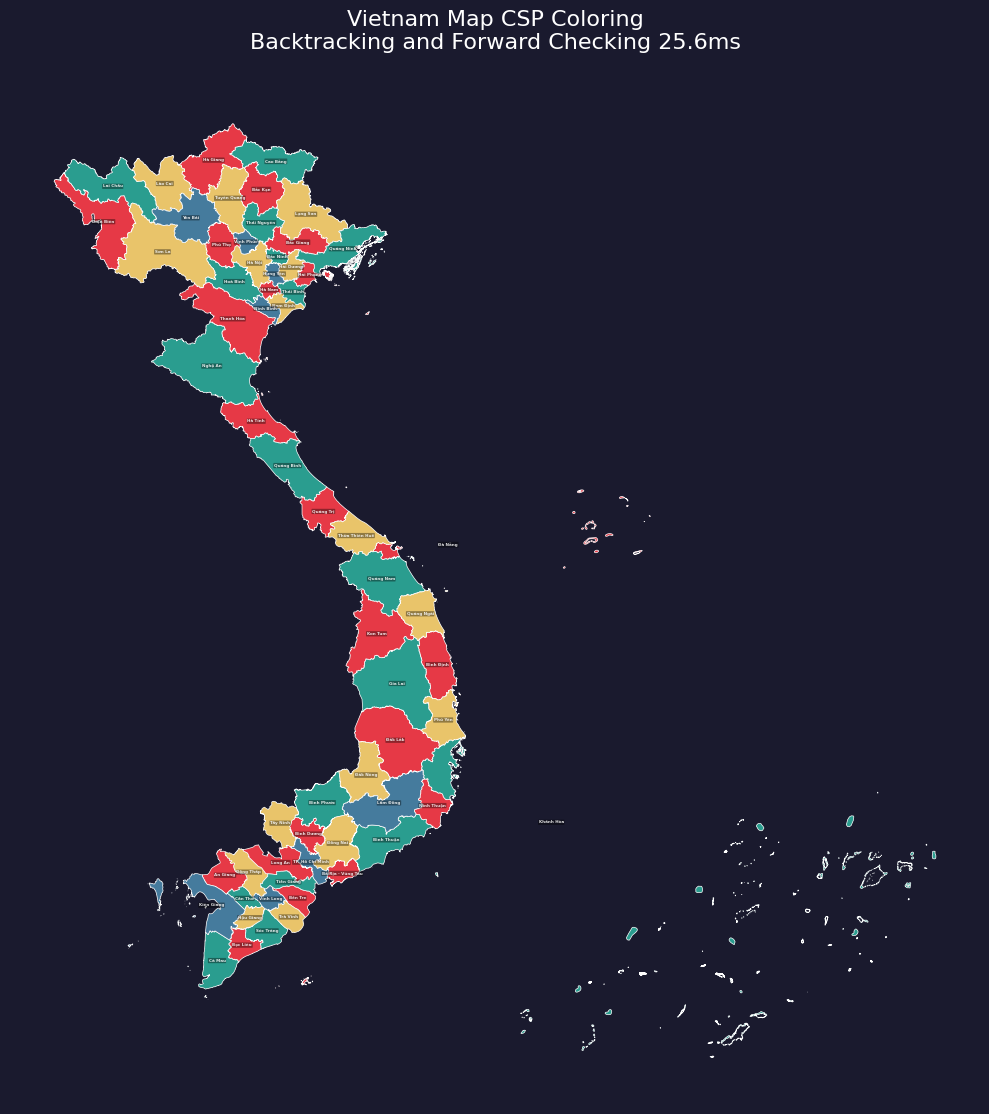

In [8]:
# ===== BACKTRACK + FORWARD CHECK =====
start_time = time.perf_counter()
backtrack_fc_solution = backtrack_fc(variables, domains, {}, neighbors)
end_time = time.perf_counter()
print(f"Backtracking + Forward Checking finished in {end_time - start_time:.4f} seconds.")

if backtrack_fc_solution:
    show_map_image(gdf,
                   solution=backtrack_fc_solution, 
                   title=f"Vietnam Map CSP Coloring\nBacktracking and Forward Checking {(end_time - start_time) * 1000:.1f}ms"
                   )
# =====================================

Backtracking + AC-3 finished in 0.0187 seconds.


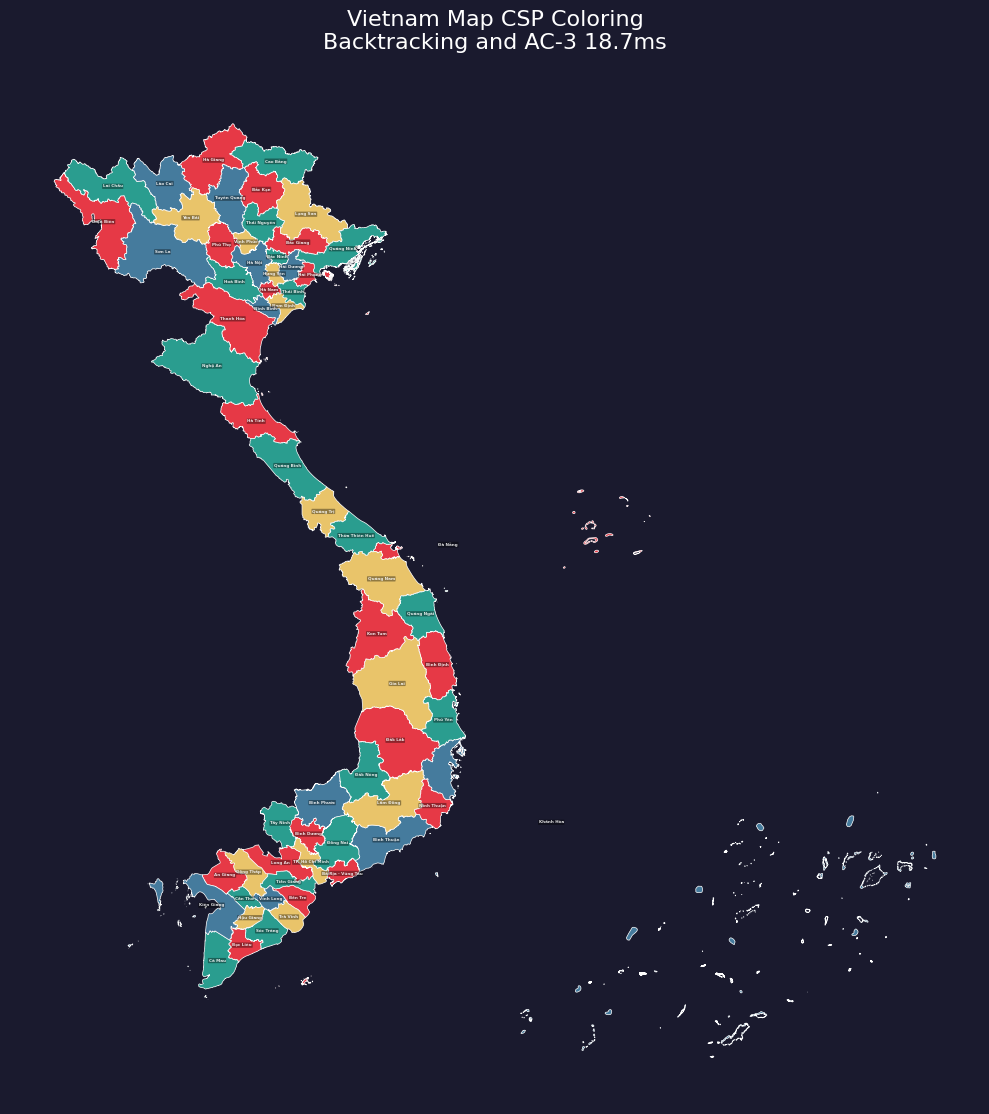

In [14]:
# ===== BACKTRACK + AC3 =====
hard_locked_domains = domains.copy()
hard_locked_provinces = {
    "Bình Phước" : ["#457B9D"], 
    "Bình Thuận" : ["#457B9D"], 
    "Khánh Hòa" : ["#457B9D"], 
    "Hà Nội": ["#457B9D"],
    "Gia Lai" : ["#E9C46A"],
    "Quảng Nam" : ["#E9C46A"],
    "Quảng Trị" : ["#E9C46A"]
}
hard_locked_domains.update(hard_locked_provinces)

start_time = time.perf_counter()
backtrack_ac3_solution = backtrack_ac3(variables, hard_locked_domains, {}, neighbors)
end_time = time.perf_counter()
print(f"Backtracking + AC-3 finished in {end_time - start_time:.4f} seconds.")

if backtrack_ac3_solution:
    show_map_image(gdf,
                   solution=backtrack_ac3_solution, 
                   title=f"Vietnam Map CSP Coloring\nBacktracking and AC-3 {(end_time - start_time) * 1000:.1f}ms"
                   )
# ===========================

Min-Conflicts solved in 76 steps
Min-Conflicts finished in 0.0098 seconds (Attempts: 1).


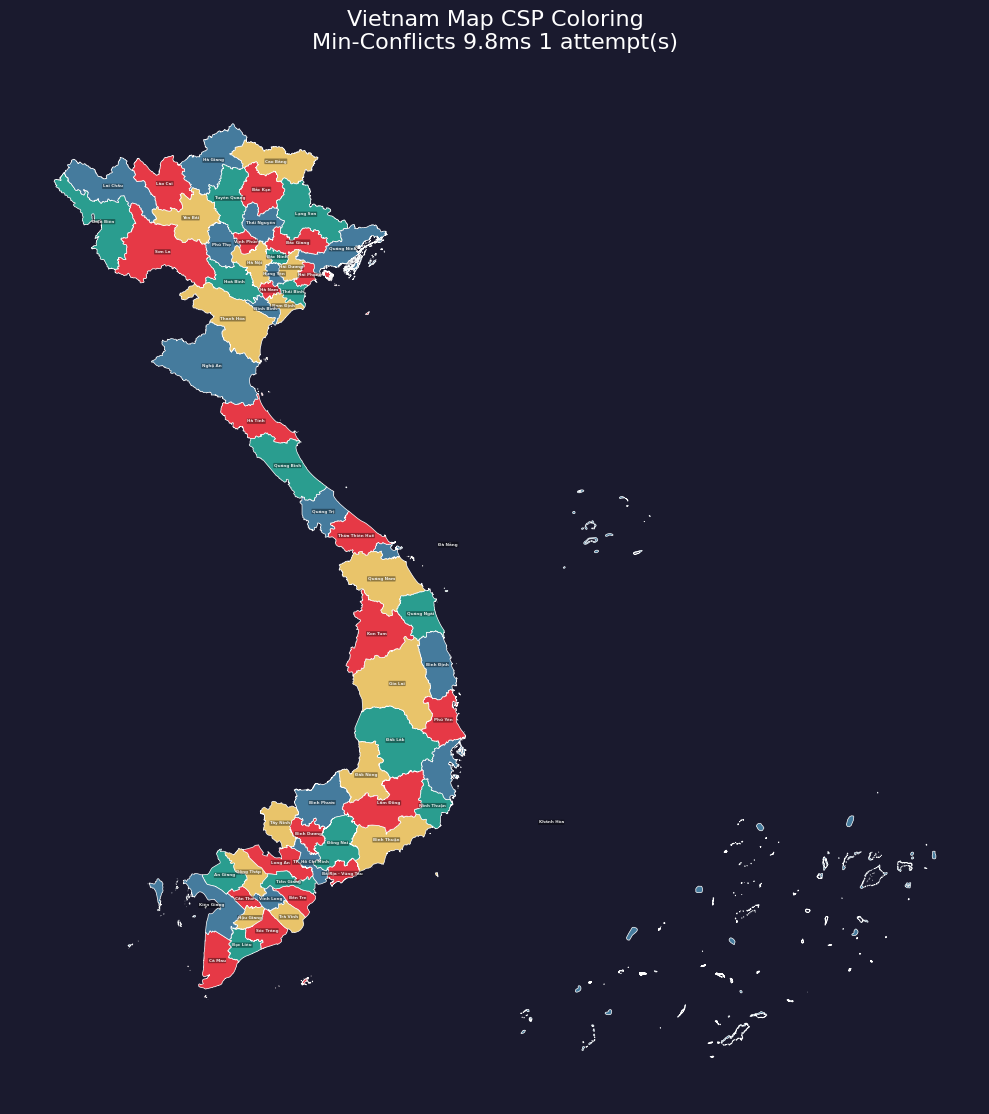

In [ ]:
# ===== MIN-CONFLICTS =====
min_conflicts_solution = None
attempts = 0

start_time = time.perf_counter()
while min_conflicts_solution is None and attempts < 5:
    attempts += 1
    min_conflicts_solution = min_conflicts(variables, domains, neighbors, max_steps=100)
end_time = time.perf_counter()
print(f"Min-Conflicts finished in {end_time - start_time:.4f} seconds (Attempts: {attempts}).")

if min_conflicts_solution:
    show_map_image(gdf,
                   solution=min_conflicts_solution, 
                   title=f"Vietnam Map CSP Coloring\nMin-Conflicts {(end_time - start_time) * 1000:.1f}ms {attempts} attempt(s)"
                   )
# =========================